# How One Outlier Bullies the Best Fit Line
A simple visual demo.

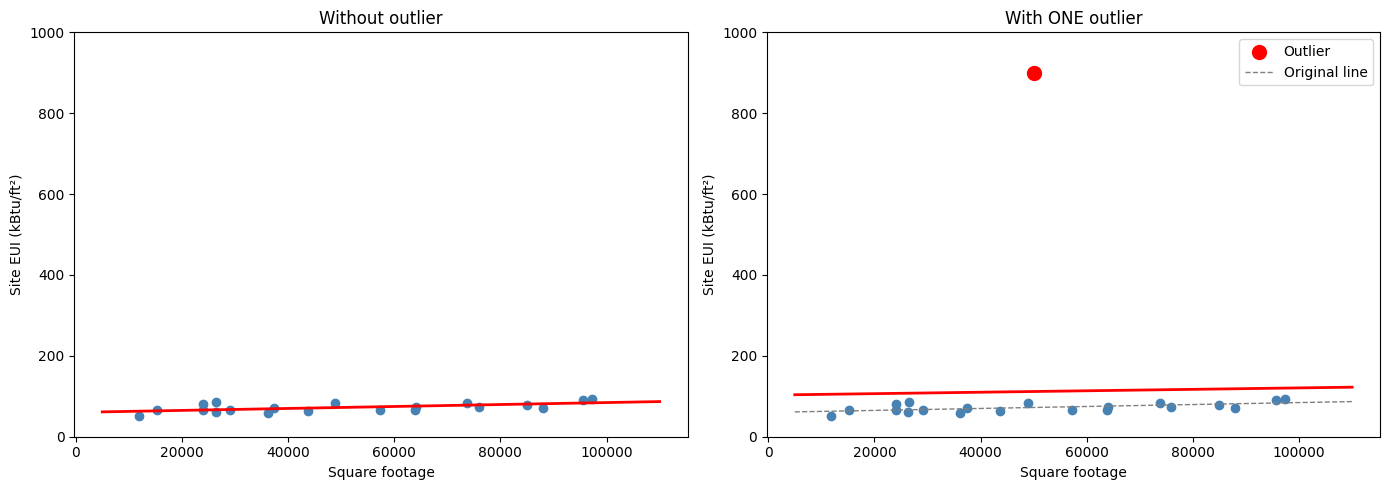

Without outlier — predicted EUI for 50k sqft building: 72.3
With outlier    — predicted EUI for 50k sqft building: 111.8


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 20 normal buildings: sqft between 10k-100k, EUI between 50-120
np.random.seed(42)
sqft = np.random.uniform(10000, 100000, 20)
eui = 60 + 0.0003 * sqft + np.random.normal(0, 10, 20)

# Fit a line WITHOUT any outlier
model_clean = LinearRegression()
model_clean.fit(sqft.reshape(-1, 1), eui)

# Now add ONE outlier: a building with sqft=50k but EUI=900 (data error)
sqft_dirty = np.append(sqft, 50000)
eui_dirty = np.append(eui, 900)

# Fit a line WITH the outlier
model_dirty = LinearRegression()
model_dirty.fit(sqft_dirty.reshape(-1, 1), eui_dirty)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(5000, 110000, 100).reshape(-1, 1)

# Left: no outlier
axes[0].scatter(sqft, eui, color='steelblue')
axes[0].plot(x_line, model_clean.predict(x_line), color='red', linewidth=2)
axes[0].set_title('Without outlier')
axes[0].set_xlabel('Square footage')
axes[0].set_ylabel('Site EUI (kBtu/ft²)')
axes[0].set_ylim(0, 1000)

# Right: with outlier
axes[1].scatter(sqft, eui, color='steelblue')
axes[1].scatter(50000, 900, color='red', s=100, zorder=5, label='Outlier')
axes[1].plot(x_line, model_dirty.predict(x_line), color='red', linewidth=2)
axes[1].plot(x_line, model_clean.predict(x_line), color='gray', linewidth=1, linestyle='--', label='Original line')
axes[1].set_title('With ONE outlier')
axes[1].set_xlabel('Square footage')
axes[1].set_ylabel('Site EUI (kBtu/ft²)')
axes[1].set_ylim(0, 1000)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Without outlier — predicted EUI for 50k sqft building: {model_clean.predict([[50000]])[0]:.1f}")
print(f"With outlier    — predicted EUI for 50k sqft building: {model_dirty.predict([[50000]])[0]:.1f}")